# Paso 01 -- Escalon 1: verificacion a ojo, metricas detalladas, inspector

Corre el entorno (`SimuladorBarcosBergen`, modelo de colas por par
origen-destino -- viajes directos punto a punto, ver `simulacion/README.md`)
con la politica de referencia ("nearest-available", `politica_base.py`)
sobre la franja manana (2 barcos, ~23 grupos / 202 personas,
`output/grupos_escalon1.csv` del paso 00).

Contenido: corrida + log de texto, verificacion de conservacion de personas,
metricas detalladas (por par, globales, por barco, por usuario, perdidas,
desglose de recompensa), graficas, animacion, e inspector de un minuto
concreto.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

BASE_DIR = Path.cwd().parent
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
sys.path.insert(0, str(BASE_DIR / "src"))

from env import SimuladorBarcosBergen
from politica_base import politica_base, asignar_flota
import metricas as met
import visualizacion as viz

cfg_sim = yaml.safe_load(open(BASE_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)
OUT_ESC = BASE_DIR / "output" / "escalon1"
OUT_ESC.mkdir(parents=True, exist_ok=True)
grupos_escalon1 = pd.read_csv(OUT_ESC / "grupos.csv")

cfg_escalon = cfg_sim["escalones"]["escalon_1"]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60


def construir_env():
    return SimuladorBarcosBergen(
        grupos_df=grupos_escalon1, matriz_tiempos=matriz_tiempos, nodos=nodos,
        num_barcos=cfg_escalon["num_barcos"], capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"],
        nodo_inicial=cfg_bb["flota"]["nodo_inicial"], paso_tiempo_min=cfg_sim["paso_tiempo_min"],
        hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )


print("Nodos:", nodos)
print(f"Barcos: {cfg_escalon['num_barcos']}, capacidad: {cfg_bb['flota']['capacidad_pasajeros']}")
print(f"Horizonte: {hora_ini_min}-{hora_fin_min} min, paso: {cfg_sim['paso_tiempo_min']} min -> {int((hora_fin_min-hora_ini_min)/cfg_sim['paso_tiempo_min'])} pasos")


Nodos: ['kleppesto', 'laksevag', 'bryggen', 'sandviken']
Barcos: 2, capacidad: 20
Horizonte: 360-540 min, paso: 2 min -> 90 pasos


## Corrida completa, con log de texto paso a paso

In [2]:
def resumir_paso(info, r):
    d = info["estado_dict"]
    barcos_str = " | ".join(
        f"{b['origen']}" + (f"->{b['destino']}({b['min_para_llegar']:.0f}m)" if not b['libre'] else "") + f":{b['ocupacion']}p"
        for b in d["barcos"]
    )
    esperando = sum(v["personas"] for v in d["demanda"].values())
    return f"t={d['tiempo']['minuto_del_dia']:4.0f}  r={r:8.3f}  mov={info['movimientos_iniciados']}  esperando={esperando:3d}  barcos: {barcos_str}"


env = construir_env()
obs, info = env.reset(seed=cfg_sim["semilla"])
log = []
reward_total = 0.0

while True:
    estado = info["_estado_obj"]
    libres = [b for b in estado.barcos if b.libre]
    decisiones = asignar_flota(libres, estado, matriz_tiempos, env.capacidad_barco, cfg_sim["recompensa"])
    accion = np.array([
        env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
        for b in estado.barcos
    ])
    obs, r, terminated, truncated, info = env.step(accion)
    reward_total += r
    log.append(resumir_paso(info, r))
    if truncated or terminated:
        break

print(f"{len(log)} pasos simulados. Recompensa total: {reward_total:.2f}\n")
print("\n".join(log))


90 pasos simulados. Recompensa total: -624.24

t= 362  r=  -0.000  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 364  r=  -0.000  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 366  r=  -0.000  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 368  r=  -0.000  mov=0  esperando= 10  barcos: B:0p | B:0p
t= 370  r=  -0.200  mov=2  esperando= 19  barcos: B->L(7m):0p | B->L(7m):0p
t= 372  r=  -0.200  mov=0  esperando= 19  barcos: B->L(5m):0p | B->L(5m):0p
t= 374  r=  -0.200  mov=0  esperando= 19  barcos: B->L(3m):0p | B->L(3m):0p
t= 376  r=  -0.200  mov=0  esperando= 19  barcos: B->L(1m):0p | B->L(1m):0p
t= 378  r=  -0.000  mov=0  esperando= 19  barcos: L:0p | L:0p
t= 380  r=  -0.139  mov=1  esperando=  6  barcos: L->B(7m):19p | L:0p
t= 382  r=  -0.574  mov=1  esperando=  6  barcos: L->B(5m):19p | L->S(7m):0p
t= 384  r=  -1.374  mov=0  esperando=  6  barcos: L->B(3m):19p | L->S(5m):0p
t= 386  r=  -2.643  mov=0  esperando=  6  barcos: L->B(1m):19p | L->S(3m):0p
t= 388  r=  -0.100  mov=0  esperando= 

## Verificacion de conservacion de personas

In [3]:
conservacion = met.verificar_conservacion(env)
for k, v in conservacion.items():
    print(f"{k}: {v}")
assert conservacion["cuadra"], "La conservacion de personas no cuadra -- hay un bug que exponer, no esconder."
print("\nOK: todas las personas generadas quedaron contabilizadas (atendidas + esperando al final + a bordo al final). Nadie se pierde -- ver simulacion/README.md.")


generadas: 202
atendidas: 202
esperando_al_final: 0
a_bordo_al_final: 0
suma: 202
cuadra: True

OK: todas las personas generadas quedaron contabilizadas (atendidas + esperando al final + a bordo al final). Nadie se pierde -- ver simulacion/README.md.


## Metricas detalladas

In [4]:
reporte = met.reporte_completo(env)

print("=== Globales ===")
for k, v in reporte["globales"].items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n=== Por par (solo pares con demanda) ===")
df_par = reporte["por_par"]
display(df_par[df_par["generadas"] > 0].round(1))


=== Globales ===
  unidades_generadas: 202
  unidades_atendidas: 202
  unidades_sin_atender_al_final: 0
  pct_atendidas: 100.00
  espera_media_min: 17.42
  sistema_medio_min: 27.19
  sistema_maximo_min: 54.02

=== Por par (solo pares con demanda) ===


,par,generadas,atendidas,sin_atender_al_final,pct_atendidas,espera_media_min,espera_maxima_min,viaje_medio_min,sistema_medio_min,sistema_maximo_min
0,kleppesto->laksevag,30,30,0,100.0,16.8,25.0,6.0,22.8,31.0
1,kleppesto->bryggen,55,55,0,100.0,21.9,33.4,12.0,33.9,45.4
2,kleppesto->sandviken,7,7,0,100.0,4.8,4.8,10.0,14.8,14.8
4,laksevag->bryggen,47,47,0,100.0,15.9,33.5,10.0,25.9,43.5
6,bryggen->kleppesto,11,11,0,100.0,15.6,15.6,12.0,27.6,27.6
7,bryggen->laksevag,16,16,0,100.0,7.9,15.1,10.0,17.9,25.1
9,sandviken->kleppesto,7,7,0,100.0,44.0,44.0,10.0,54.0,54.0
11,sandviken->bryggen,29,29,0,100.0,14.6,29.0,8.0,22.6,37.0


In [5]:
print("=== Por barco ===")
display(reporte["por_barco"].round(1))

print("\n=== Por usuario (percentiles, minutos) ===")
for k, v in reporte["por_usuario"].items():
    print(f"  {k}: {v}")

print("\n=== Sin atender al final (backlog, no perdidas) ===")
display(reporte["sin_atender_al_final"])

reporte["por_par"].to_csv(OUT_ESC / "metricas_por_par.csv", index=False)
reporte["por_barco"].to_csv(OUT_ESC / "metricas_por_barco.csv", index=False)


=== Por barco ===


,barco_id,movimientos,tiempo_navegado_min,ocupacion_media,ocupacion_maxima,pct_ocioso,ruta_mas_frecuente
0,barco_0,18,130,4.8,19,28.6,bryggen->laksevag (4x)
1,barco_1,17,136,3.9,20,25.3,bryggen->laksevag (3x)



=== Por usuario (percentiles, minutos) ===
  espera_min: {'p50': 15.620000000000005, 'p90': 33.370000000000005, 'p95': 33.49000000000001, 'max': 44.01999999999998}
  viaje_min: {'p50': 10.0, 'p90': 12.0, 'p95': 12.0, 'max': 12.0}
  sistema_min: {'p50': 25.139999999999986, 'p90': 43.49000000000001, 'p95': 45.370000000000005, 'max': 54.01999999999998}

=== Sin atender al final (backlog, no perdidas) ===


,par,sin_atender


## Donde viven los logs (para las metricas de arriba)

Todo lo que alimenta `metricas.py` vive, EN MEMORIA, sobre el objeto `env`
mientras dura la corrida -- no se guarda solo con correr `env.step()`:

- `env.log_eventos`: una fila por cada `sube` / `baja` / `perdida` /
  `decision` / `movimiento`, con su minuto.
- `env.log_recompensa`: el desglose de la recompensa (incomodidad,
  movimiento, total) de cada paso.
- `env.historial_estados`: una foto (`estado.to_dict()`) por paso -- lo que
  usan la animacion y el inspector.
- `env.atendidas_historico` / `env.perdidas_historico`: las unidades ya
  resueltas (listas de objetos `Unidad`), no un log de eventos.

Aqui se guardan a disco (CSV), para poder auditarlos sin volver a correr la
simulacion.


In [6]:
pd.DataFrame(env.log_eventos).to_csv(OUT_ESC / "log_eventos.csv", index=False)
pd.DataFrame(env.log_recompensa).to_csv(OUT_ESC / "log_recompensa.csv", index=False)
print(f"{len(env.log_eventos)} eventos guardados en log_eventos.csv")
print(f"{len(env.log_recompensa)} pasos de recompensa guardados en log_recompensa.csv")
pd.DataFrame(env.log_eventos).head(10)


486 eventos guardados en log_eventos.csv
90 pasos de recompensa guardados en log_recompensa.csv


,tipo,minuto,barco_id,decision,desde,hasta,ocupacion,unidad_id,par,tiempo_espera,tiempo_viaje
0,decision,360.0,barco_0,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,decision,360.0,barco_1,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,decision,362.0,barco_0,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,decision,362.0,barco_1,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,decision,364.0,barco_0,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,decision,364.0,barco_1,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,decision,366.0,barco_0,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,decision,366.0,barco_1,esperar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,decision,368.0,barco_0,laksevag,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,movimiento,368.0,barco_0,NaN,bryggen,laksevag,0.0,NaN,NaN,NaN,NaN


## Graficas

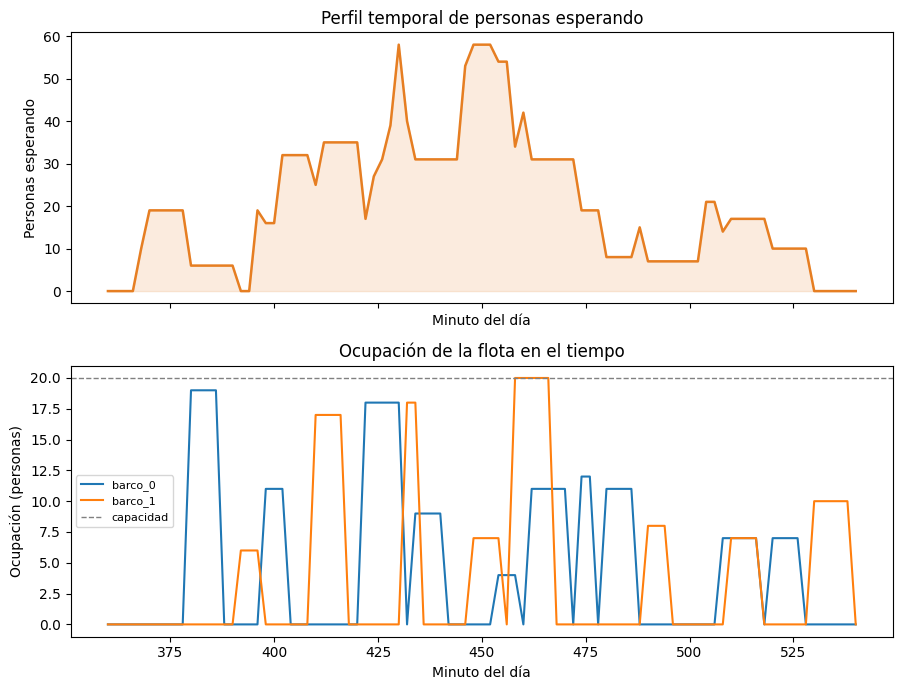

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
viz.graficar_perfil_espera(env, ax=axs[0])
viz.graficar_ocupacion_flota(env, ax=axs[1])
fig.tight_layout()
fig.savefig(OUT_ESC / "perfil_y_ocupacion.png", dpi=150)
plt.show()


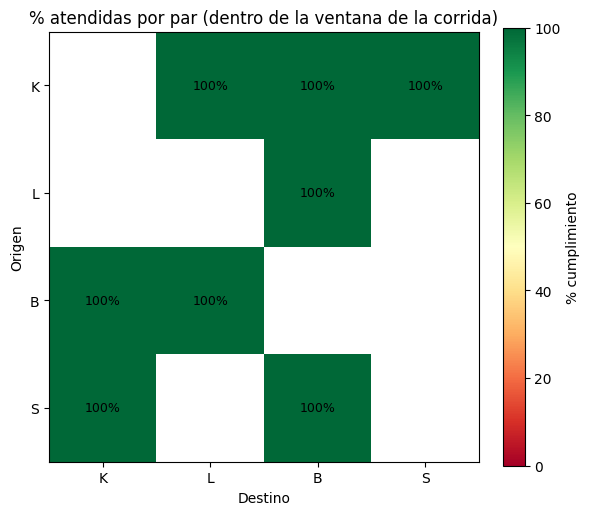

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.5))
viz.graficar_heatmap_cumplimiento(env, ax=ax)
fig.tight_layout()
fig.savefig(OUT_ESC / "heatmap_cumplimiento.png", dpi=150)
plt.show()


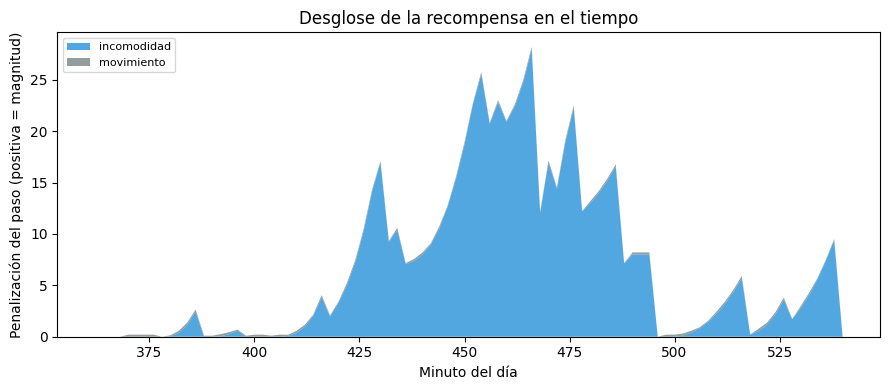

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
viz.graficar_desglose_recompensa(env, ax=ax)
fig.tight_layout()
fig.savefig(OUT_ESC / "desglose_recompensa.png", dpi=150)
plt.show()


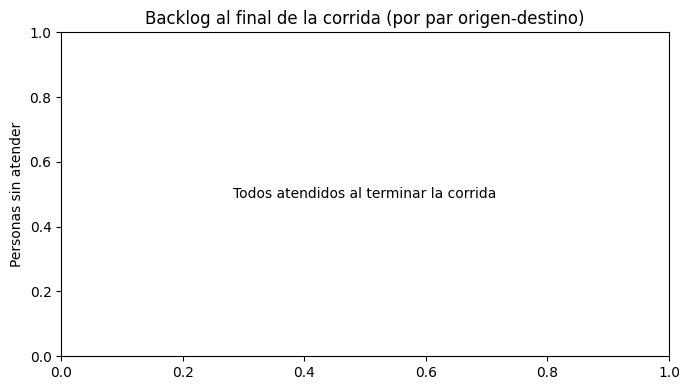

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
viz.graficar_sin_atender_al_final(env, ax=ax)
fig.tight_layout()
fig.savefig(OUT_ESC / "sin_atender_al_final.png", dpi=150)
plt.show()


## Visualizacion: mapa real + rutas navegables + barcos en movimiento

Reusa el mapa base y `bergen-boats/02_ruteo_navegable/output/rutas_navegables.geojson`
(persistidas en este mismo trabajo) para que los barcos se muevan bordeando
tierra, no en linea recta. El historial completo de la corrida ya vive en
`env.historial_estados` (lo registra el propio entorno, no hace falta
juntarlo a mano en el bucle de arriba).


In [11]:
gdf_nodos, gdf_rutas = viz.cargar_capas_mapa(cfg_bb, BB_DIR / "02_ruteo_navegable" / "output" / "rutas_navegables.geojson")

# El mapa de fondo se descarga UNA sola vez aqui y se reusa en la animacion,
# el inspector y el reproductor de abajo -- pedirlo varias veces depende de
# un servidor de tiles externo que a veces tarda, sin necesidad.
fondo_mapa = viz.descargar_fondo_mapa(gdf_nodos)

out_gif = OUT_ESC / "animacion.gif"
viz.animar_corrida(env.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env.capacidad_barco, out_gif, fps=6, fondo=fondo_mapa)
print("Guardado:", out_gif)
plt.close("all")


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\simulacion\output\escalon1\animacion.gif


## Inspector: pausar en un minuto concreto, y reproductor tipo video

`inspeccionar(minuto, ...)` funciona siempre (no requiere kernel vivo) --
usado abajo con dos minutos concretos.

`reproductor_interactivo(env, ...)` es el reproductor completo: boton de
reproducir/pausar, barra de tiempo para saltar a cualquier paso (adelante o
atras), mapa animado, y un panel de texto con el estado completo de ese
paso (barcos, colas, que decidio cada barco, recompensa con su desglose).
SOLO funciona con un kernel de Jupyter vivo (abrelo en VS Code / Jupyter
Lab y corre las celdas tu mismo) -- en este notebook ya ejecutado y
guardado, la celda de abajo no responde a los botones.


=== Minuto 400 ===

Barcos:
  barco_0: S->B (3 min), ocupación=11
  barco_1: B->L (7 min), ocupación=0

Colas (pares con gente esperando):
  K->B: 8 personas, la más antigua lleva 2.1 min
  L->B: 8 personas, la más antigua lleva 5.9 min

Recompensa del paso: -0.200
  incomodidad = 0.000
  movimiento  = 0.200


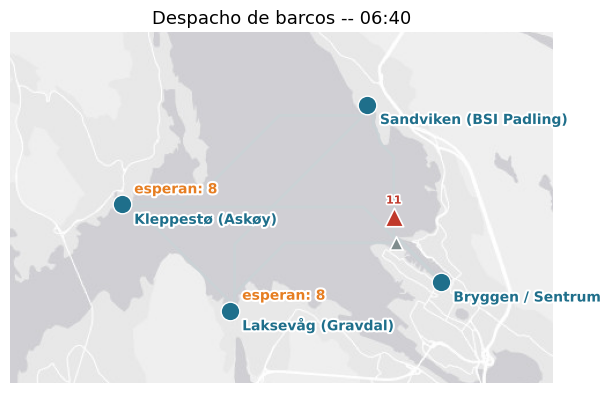

In [12]:
fig = viz.inspeccionar(400, env, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
fig.savefig(OUT_ESC / "inspeccion_minuto400.png", dpi=150, bbox_inches="tight")
plt.show()


=== Minuto 420 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: bryggen
  barco_1: B->K (10 min), ocupación=0

Colas (pares con gente esperando):
  K->L: 10 personas, la más antigua lleva 8.5 min
  K->B: 18 personas, la más antigua lleva 22.1 min
  S->K: 7 personas, la más antigua lleva 18.0 min

Recompensa del paso: -3.402
  incomodidad = 3.302
  movimiento  = 0.100


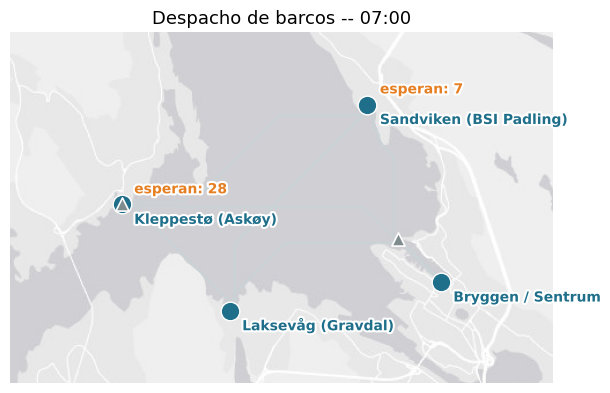

In [13]:
fig = viz.inspeccionar(420, env, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
plt.show()


In [14]:
# Solo funciona con un kernel de Jupyter vivo (ver celda de arriba) -- si estas
# viendo este notebook ya ejecutado y guardado, esta celda no sera interactiva.
viz.reproductor_interactivo(env, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
plt.close("all")  # libera figuras acumuladas antes de las celdas siguientes


## Verificacion de reproducibilidad

In [15]:
sys.path.insert(0, str((BASE_DIR / "../demand/src").resolve()))
import llegadas as demand_llegadas
import masas as demand_masas

DEMAND_DIR = (BASE_DIR / "../demand").resolve()
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")
resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
bb_cfg_path2 = (DEMAND_DIR / cfg_demand["fuentes_externas"]["nodos_config"]).resolve()
cfg_bb2 = yaml.safe_load(open(bb_cfg_path2, encoding="utf-8"))
conexiones_fuertes = cfg_bb2["garantia"]["conexiones_fuertes"]


def generar_grupos_con_semilla(semilla):
    cfg_mod = dict(cfg_demand)
    cfg_mod["demanda"] = dict(cfg_demand["demanda"])
    cfg_mod["demanda"]["porcentaje_poblacion_dia"] = cfg_escalon["porcentaje_poblacion_dia"]
    rng = np.random.default_rng(semilla)
    grupos = demand_llegadas.generar_llegadas_dia(
        cfg_mod, intensidad_od, conexiones_fuertes, poblacion_total_zonas,
        es_fin_de_semana=False, rng=rng, dia_id="repro",
    )
    hora_ini, hora_fin = cfg_escalon["horas"]
    return grupos[(grupos["hora"] >= hora_ini) & (grupos["hora"] < hora_fin)].reset_index(drop=True)


def correr_una_vez(grupos_df):
    env2 = SimuladorBarcosBergen(
        grupos_df=grupos_df, matriz_tiempos=matriz_tiempos, nodos=nodos,
        num_barcos=cfg_escalon["num_barcos"], capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"],
        nodo_inicial=cfg_bb["flota"]["nodo_inicial"], paso_tiempo_min=cfg_sim["paso_tiempo_min"],
        hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )
    obs, info = env2.reset(seed=cfg_sim["semilla"])
    total = 0.0
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        decisiones = asignar_flota(libres, estado, matriz_tiempos, env2.capacidad_barco, cfg_sim["recompensa"])
        accion = np.array([
            env2.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
            for b in estado.barcos
        ])
        obs, r, terminated, truncated, info = env2.step(accion)
        total += r
        if truncated or terminated:
            break
    return round(total, 6), len(env2.atendidas_historico), sum(len(c) for c in env2.colas.values())


grupos_semilla_42_a = generar_grupos_con_semilla(42)
grupos_semilla_42_b = generar_grupos_con_semilla(42)
grupos_semilla_43 = generar_grupos_con_semilla(43)

r1 = correr_una_vez(grupos_semilla_42_a)
r2 = correr_una_vez(grupos_semilla_42_b)
r3 = correr_una_vez(grupos_semilla_43)
print("Semilla 42, generacion a:", r1)
print("Semilla 42, generacion b:", r2)
print("Semilla 43:              ", r3)
print("Misma semilla de demanda -> misma corrida completa:", r1 == r2)
print("Semilla distinta -> corrida distinta:", r1 != r3)


Semilla 42, generacion a: (-624.240882, 202, 0)
Semilla 42, generacion b: (-624.240882, 202, 0)
Semilla 43:               (-578.041383, 213, 26)
Misma semilla de demanda -> misma corrida completa: True
Semilla distinta -> corrida distinta: True
